In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = pd.read_csv("iris (1).csv")

# Features and target
X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose k value
k = 5

# Create model
knn = KNeighborsClassifier(n_neighbors=k)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
diabetes = pd.read_csv("diabetes.csv")

# Features and target
X = diabetes.iloc[:, :-1]
y = diabetes.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Choose k
k = 7

# KNN model
knn = KNeighborsClassifier(n_neighbors=k)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.6818181818181818
Confusion Matrix:
 [[78 21]
 [28 27]]


Best K value: 11
Accuracy: 0.7540983606557377
Confusion Matrix:
 [[20  9]
 [ 6 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



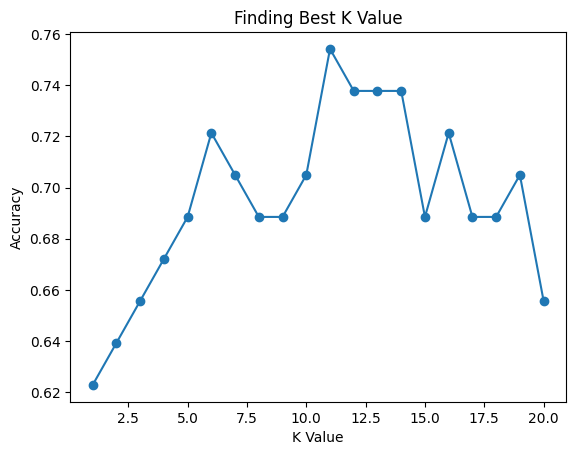

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
heart = pd.read_csv("heart.csv")

# Features and target
X = heart.drop("target", axis=1)
y = heart["target"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Find best K value
scores = []

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,y_pred))

best_k = scores.index(max(scores)) + 1
print("Best K value:", best_k)

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test,y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test,y_pred))

# Plot accuracy vs K
plt.plot(range(1,21),scores,marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Finding Best K Value")
plt.show()